# Level 1 - Task 2: Build a Simple Linear Regression Model
**Codveda Technology — Machine Learning Internship**

**Goal:** Build a linear regression model to predict a continuous variable — house prices.

**Dataset:** `house_prices.csv` (Boston Housing dataset, 506 rows, 13 features, target = `MEDV`, median home value in $1000s)

**Steps covered:**
1. Load and preprocess the dataset
2. Train a linear regression model using scikit-learn
3. Interpret the model coefficients
4. Evaluate using R-squared and MSE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


In [ ]:
import os
print(os.listdir("."))

['.config', 'data', 'sample_data']


In [ ]:
import os
print(os.listdir("data"))

[]


In [15]:
import os
print("Root:", os.listdir("."))
print("Data folder:", os.listdir("data"))

Root: ['.config', 'data', 'sample_data']
Data folder: ['.ipynb_checkpoints', 'house_prices.csv']


In [16]:
columns = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"]
df = pd.read_csv("data/house_prices.csv", header=None, names=columns, sep=r"\s+")
print("Shape:", df.shape)

Shape: (506, 14)


## 1. Load and preprocess the dataset
The file has no header row, so we assign the standard Boston Housing column names.

In [17]:
columns = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"]
df = pd.read_csv("data/house_prices.csv", header=None, names=columns, sep=r"\s+")

print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
df.head()


Shape: (506, 14)
Missing values: 0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [18]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [19]:
X = df.drop(columns=["MEDV"])
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (404, 13) Test: (102, 13)


## 2. Train the linear regression model

In [20]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


## 3. Interpret the model coefficients
Because features are standardized, coefficient magnitude reflects each feature's relative influence on predicted price.

Intercept: 22.797

LSTAT     -3.611658
DIS       -3.081908
PTRATIO   -2.037752
NOX       -2.022319
TAX       -1.767014
CRIM      -1.002135
AGE       -0.176048
INDUS      0.278065
ZN         0.696269
CHAS       0.718738
B          1.129568
RAD        2.251407
RM         3.145240
dtype: float64


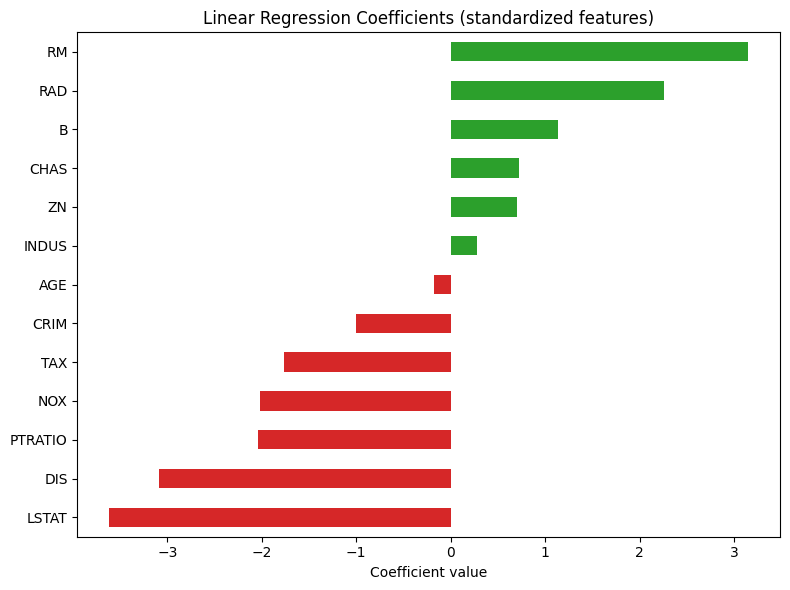

In [21]:
coef_series = pd.Series(model.coef_, index=X.columns).sort_values()
print(f"Intercept: {model.intercept_:.3f}\n")
print(coef_series)

fig, ax = plt.subplots(figsize=(8, 6))
coef_series.plot(kind="barh", ax=ax, color=["#d62728" if v < 0 else "#2ca02c" for v in coef_series])
ax.set_title("Linear Regression Coefficients (standardized features)")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()


**Interpretation:** `RM` (average rooms per dwelling) and `RAD` (accessibility to highways) push price up the most, while `LSTAT` (% lower-status population) and `DIS` (distance to employment centers) push price down the most.

## 4. Evaluate the model

In [22]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")


R-squared: 0.6688
MSE: 24.2911
RMSE: 4.9286


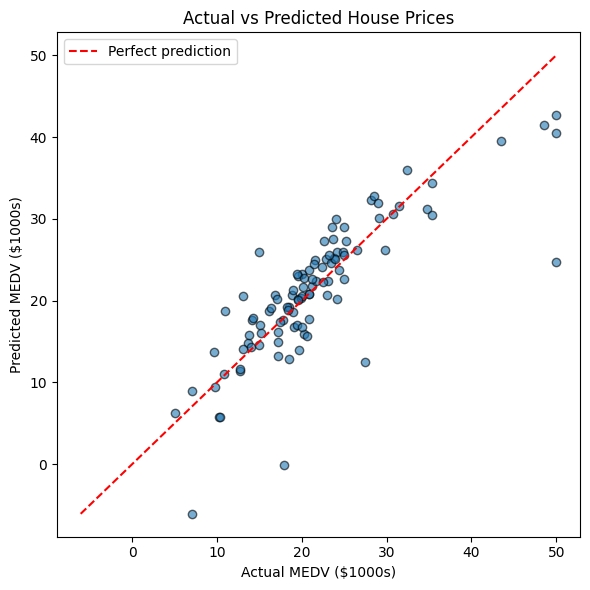

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred, alpha=0.6, edgecolor="k")
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual MEDV ($1000s)")
ax.set_ylabel("Predicted MEDV ($1000s)")
ax.set_title("Actual vs Predicted House Prices")
ax.legend()
plt.tight_layout()
plt.show()


## Summary
- Trained a linear regression model on the Boston Housing dataset
- R² ≈ 0.67, meaning the model explains about 67% of the variance in house prices
- `RM` (rooms) and `LSTAT` (% lower status population) are the strongest predictors

**Tools used:** Python, pandas, scikit-learn
